# 4. Hannah Discussion Visualization

This notebook compares predefined and autonomous grouping results across multiple LLM runs using slices, 3D panels, and property-space crossplots.


## Block 1: Single-Depth Comparison Across Four Models

Plot one common depth slice for GPT, GEMINI, CLAUDE, and QWEN in Density, Susceptibility, and Geo Group columns.


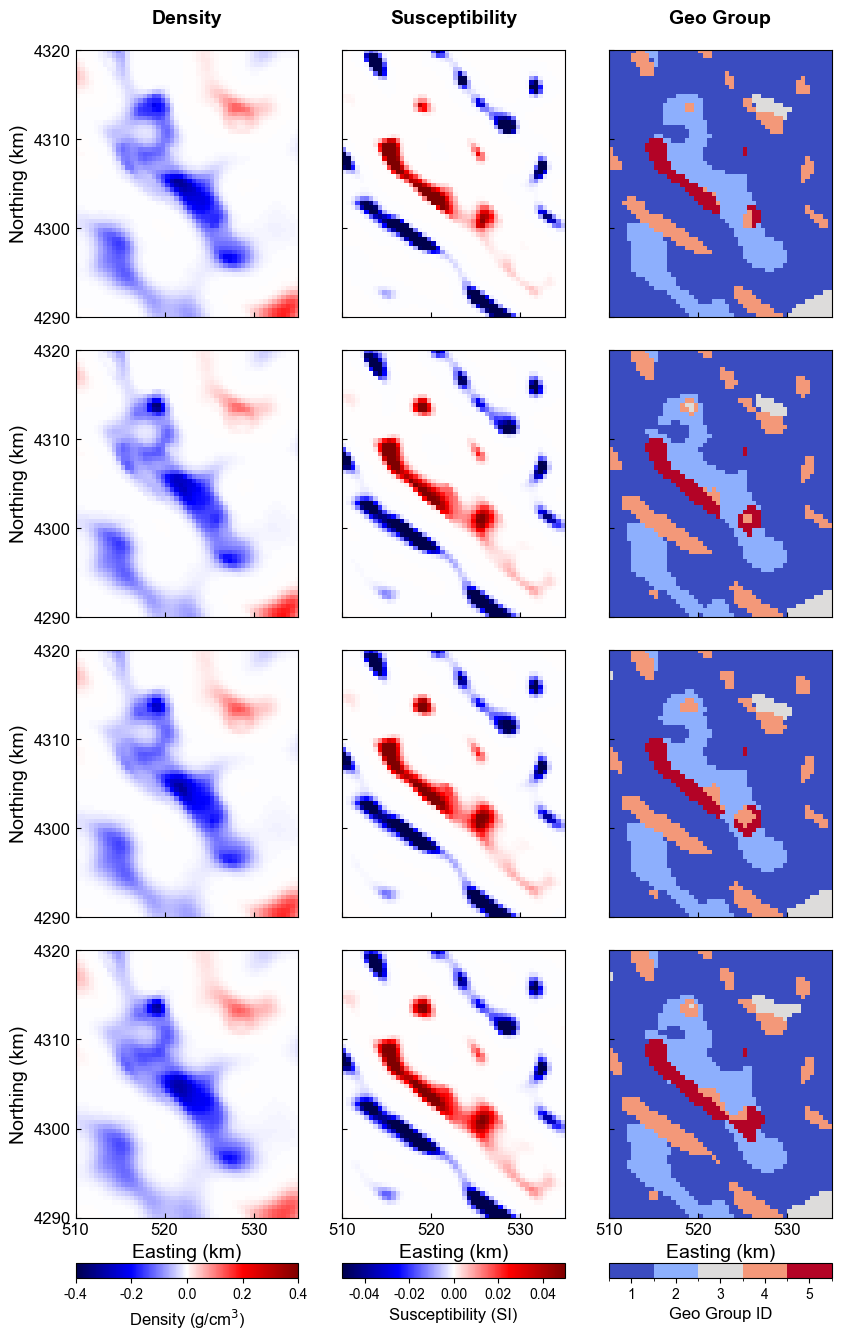

Saved: Figure\Figure8_Hannah_comparison_LLM.png


In [11]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from pathlib import Path

# -------------------------
# Block 1: Single-Depth Comparison Across Four Models
# -------------------------
ROOT = Path.cwd()

model_specs = [
    ("GPT", ROOT / "Hannah_Inversion_GPT"),
    ("GEMINI", ROOT / "Hannah_Inversion_gemini"),
    ("CLAUDE", ROOT / "Hannah_Inversion_claude"),
    ("QWEN", ROOT / "Hannah_Inversion_Qwen"),
]

depth_target_m = -2500.0

dens_vmin, dens_vmax = -0.4, 0.4
susc_vmin, susc_vmax = -0.05, 0.05

# Global font settings (same style as 3_1 notebook)
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["axes.unicode_minus"] = False

# -------------------------
# Helpers
# -------------------------
from notebook_geo_helpers import read_ubc_tensor_mesh

def load_model_pack(model_name: str, proj_dir: Path, z_target_m: float):
    dens = np.load(proj_dir / "inversion_result" / "joint_density_core.npy")
    susc = np.load(proj_dir / "inversion_result" / "joint_susceptibility_core.npy")

    geo_path = proj_dir / "geology_models" / "geo_id_3d.npy"
    if not geo_path.exists():
        geo_path = proj_dir / "geology_models" / "unit_id_3d.npy"
    geo = np.load(geo_path).astype(int)

    mesh_path = proj_dir / "mesh" / "mesh_core.msh"
    (nx, ny, nz), x_edges, y_edges, _, _, _, z_centers = read_ubc_tensor_mesh(mesh_path)

    if dens.shape != susc.shape or dens.shape != geo.shape:
        raise ValueError(
            f"Shape mismatch in {model_name}: dens={dens.shape}, susc={susc.shape}, geo={geo.shape}"
        )
    if dens.shape != (nx, ny, nz):
        raise ValueError(f"Mesh mismatch in {model_name}: mesh={(nx, ny, nz)} vs data={dens.shape}")

    k = int(np.argmin(np.abs(z_centers - z_target_m)))

    return {
        "model": model_name,
        "dens": dens,
        "susc": susc,
        "geo": geo,
        "k": k,
        "x_edges": x_edges,
        "y_edges": y_edges,
    }


# -------------------------
# Read model packs
# -------------------------
rows = []
all_geo_vals = []
for model_name, proj_dir in model_specs:
    pack = load_model_pack(model_name, proj_dir, depth_target_m)
    rows.append(pack)
    all_geo_vals.extend(np.unique(pack["geo"].astype(int)).tolist())

geo_values = np.array(sorted(set(int(v) for v in all_geo_vals)), dtype=int)
if geo_values.size == 0:
    geo_values = np.array([0], dtype=int)

if geo_values.size == 1:
    geo_bounds = np.array([geo_values[0] - 0.5, geo_values[0] + 0.5], dtype=float)
else:
    geo_bounds = np.empty(geo_values.size + 1, dtype=float)
    geo_bounds[1:-1] = 0.5 * (geo_values[:-1] + geo_values[1:])
    geo_bounds[0] = geo_values[0] - 0.5
    geo_bounds[-1] = geo_values[-1] + 0.5

geo_base = plt.get_cmap("coolwarm")
geo_colors = geo_base(np.linspace(0.0, 1.0, geo_values.size))
cmap_geo = ListedColormap(geo_colors, name="coolwarm_discrete_geo")
norm_geo = BoundaryNorm(geo_bounds, cmap_geo.N, clip=True)
cmap_cont = plt.get_cmap("seismic")


# -------------------------
# Plot: 4x3 comparison figure in Hannah style
# -------------------------
n_rows = len(rows)
if n_rows == 0:
    raise ValueError("No model rows loaded.")

fig = plt.figure(figsize=(10, 15), constrained_layout=False)
gs = fig.add_gridspec(
    nrows=n_rows + 1,
    ncols=3,
    height_ratios=[1.0] * n_rows + [0.11],
    left=0.16,
    right=0.95,
    top=0.94,
    bottom=0.12,
    wspace=0.04,
    hspace=0.15,
)

axes = np.empty((n_rows, 3), dtype=object)
for r in range(n_rows):
    for c in range(3):
        axes[r, c] = fig.add_subplot(gs[r, c])

m_d_ref = None
m_s_ref = None
m_g_ref = None

for r, row in enumerate(rows):
    ax_d, ax_s, ax_g = axes[r, 0], axes[r, 1], axes[r, 2]

    k = row["k"]
    x_edges_km = row["x_edges"] / 1000.0
    y_edges_km = row["y_edges"] / 1000.0

    dens_slice = row["dens"][:, :, k].T
    susc_slice = row["susc"][:, :, k].T
    geo_slice = row["geo"][:, :, k].T

    m_d = ax_d.imshow(
        dens_slice,
        origin="lower",
        extent=[x_edges_km[0], x_edges_km[-1], y_edges_km[0], y_edges_km[-1]],
        cmap=cmap_cont,
        vmin=dens_vmin,
        vmax=dens_vmax,
        interpolation="nearest",
    )
    m_s = ax_s.imshow(
        susc_slice,
        origin="lower",
        extent=[x_edges_km[0], x_edges_km[-1], y_edges_km[0], y_edges_km[-1]],
        cmap=cmap_cont,
        vmin=susc_vmin,
        vmax=susc_vmax,
        interpolation="nearest",
    )
    m_g = ax_g.imshow(
        geo_slice,
        origin="lower",
        extent=[x_edges_km[0], x_edges_km[-1], y_edges_km[0], y_edges_km[-1]],
        cmap=cmap_geo,
        norm=norm_geo,
        interpolation="nearest",
    )

    for c, ax in enumerate((ax_d, ax_s, ax_g)):
        ax.set_xlim(x_edges_km[0], x_edges_km[-1])
        ax.set_ylim(y_edges_km[0], y_edges_km[-1])

        ax.set_xticks([510, 520, 530])
        ax.set_yticks(np.linspace(y_edges_km[0], y_edges_km[-1], 4))
        ax.tick_params(direction="in", labelsize=12)

        if r == n_rows - 1:
            ax.set_xlabel("Easting (km)", fontsize=14)
        else:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)

        if c == 0:
            ax.set_ylabel("Northing (km)", fontsize=14)
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

    if m_d_ref is None:
        m_d_ref = m_d
    if m_s_ref is None:
        m_s_ref = m_s
    if m_g_ref is None:
        m_g_ref = m_g


# Column headers at top
col_titles = ["Density", "Susceptibility", "Geo Group"]
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    xc = 0.5 * (pos.x0 + pos.x1)
    fig.text(xc, 0.955, title, ha="center", va="bottom", fontsize=14, fontweight="bold")

# Bottom colorbars (3 shared bars)
fig.canvas.draw()
cb_h = 0.010
cb_gap = 0.030

pos_d = axes[n_rows - 1, 0].get_position()
pos_s = axes[n_rows - 1, 1].get_position()
pos_g = axes[n_rows - 1, 2].get_position()

cax_d = fig.add_axes([pos_d.x0, pos_d.y0 - cb_gap - cb_h, pos_d.width, cb_h])
cax_s = fig.add_axes([pos_s.x0, pos_s.y0 - cb_gap - cb_h, pos_s.width, cb_h])
cax_g = fig.add_axes([pos_g.x0, pos_g.y0 - cb_gap - cb_h, pos_g.width, cb_h])

cbar_d = fig.colorbar(m_d_ref, cax=cax_d, orientation="horizontal")
cbar_d.set_label(r"Density (g/cm$^3$)", fontsize=12)

cbar_s = fig.colorbar(m_s_ref, cax=cax_s, orientation="horizontal")
cbar_s.set_label("Susceptibility (SI)", fontsize=12)

cbar_g = fig.colorbar(m_g_ref, cax=cax_g, orientation="horizontal")
cbar_g.set_label("Geo Group ID", fontsize=12)
if geo_values.size <= 12:
    cbar_g.set_ticks(geo_values)
else:
    step = int(np.ceil(geo_values.size / 12))
    cbar_g.set_ticks(geo_values[::step])

out_dir = ROOT / "Figure"
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "Figure8_Hannah_comparison_LLM.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.relative_to(ROOT)}")

## Block 2: 3D Comparison of Key Geologic Domains

Render a 4x3 3D panel set showing no-background geology, Geo ID 4, and Geo ID 5 for each model.


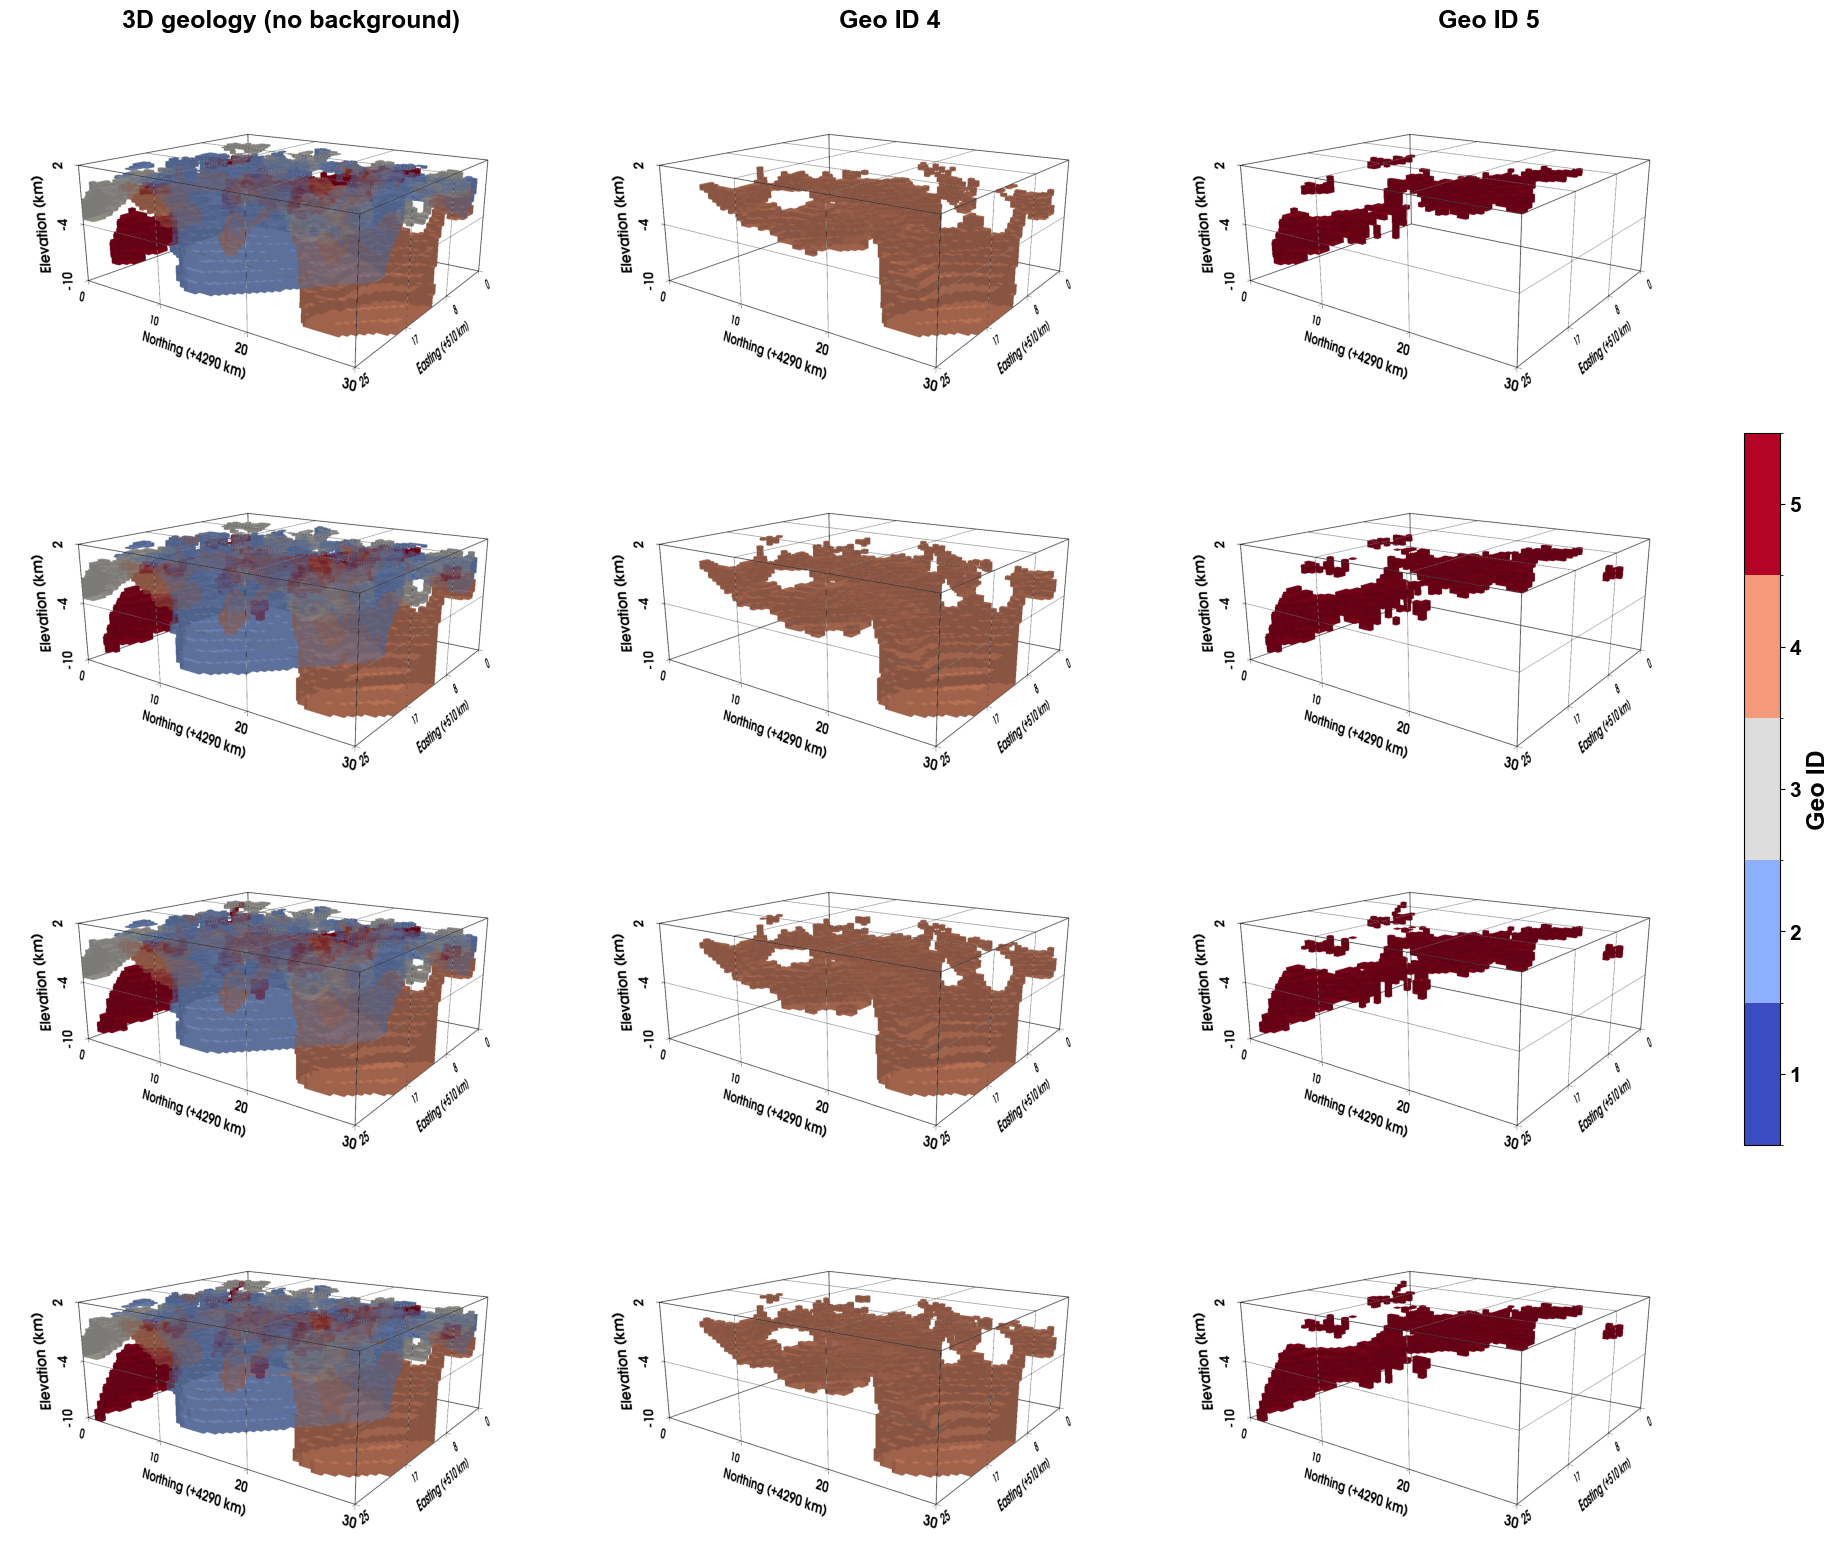

Saved: Figure\FigureS3_Hannah_geo_3d_comparison_LLM.png


In [12]:
# -------------------------
# Block 2: 3D Comparison of Key Geologic Domains (4x3)
# Rows: GPT, GEMINI, CLAUDE, QWEN
# -------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path
import pyvista as pv

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]

ROOT = Path.cwd()

model_specs = [
    ("GPT", ROOT / "Hannah_Inversion_GPT"),
    ("GEMINI", ROOT / "Hannah_Inversion_gemini"),
    ("CLAUDE", ROOT / "Hannah_Inversion_claude"),
    ("QWEN", ROOT / "Hannah_Inversion_Qwen"),
]


from notebook_geo_helpers import read_ubc_tensor_mesh


def setup_bounds(plotter, grid_obj, font_size=30):
    xmin, xmax, ymin, ymax, zmin, zmax = grid_obj.bounds

    # Match 3_1 style: relative km axes from local origin.
    xmin_km, xmax_km = xmin / 1000.0, xmax / 1000.0
    ymin_km, ymax_km = ymin / 1000.0, ymax / 1000.0
    zmin_km, zmax_km = zmin / 1000.0, zmax / 1000.0
    dx_km = xmax_km - xmin_km
    dy_km = ymax_km - ymin_km

    actor = plotter.show_bounds(
        grid="front",
        location="outer",
        all_edges=False,
        xtitle=f"Easting (+{xmin_km:.0f} km)",
        ytitle=f"Northing (+{ymin_km:.0f} km)",
        ztitle="Elevation (km)",
        axes_ranges=[0.0, dx_km, 0.0, dy_km, zmin_km, zmax_km],
        fmt="%.0f",
        font_size=font_size,
        n_xlabels=4,
        n_ylabels=4,
        n_zlabels=3,
    )

    actor.SetTickLocationToOutside()
    # Match 3_1 style: X/Y integer labels, Z one decimal.
    if hasattr(actor, "SetLabelFormat"):
        actor.SetLabelFormat("%.1f")
    if hasattr(actor, "SetXLabelFormat"):
        actor.SetXLabelFormat("%.0f")
    if hasattr(actor, "SetYLabelFormat"):
        actor.SetYLabelFormat("%.0f")
    if hasattr(actor, "SetZLabelFormat"):
        actor.SetZLabelFormat("%.1f")
    actor.label_offset = 30


def setup_camera(plotter, grid_obj, zoom=1.0):
    xmin, xmax, ymin, ymax, zmin, zmax = grid_obj.bounds
    center = ((xmin + xmax) / 2, (ymin + ymax) / 2, (zmin + zmax) / 2)
    dx, dy, dz = xmax - xmin, ymax - ymin, zmax - zmin
    plotter.camera_position = [
        (center[0] + 2 * dx, center[1] + 1.2*dy, center[2] + 1.5 * dz),
        center,
        (0, 0, 1),
    ]
    plotter.camera.zoom(zoom)



def render_geo_panel(grid, mask, cmap_geo, clim, window_size=(1500, 950)):
    if not np.any(mask):
        return None

    grid_show = grid.extract_cells(mask)
    p = pv.Plotter(off_screen=True, window_size=window_size)
    p.set_background("white")
    p.add_mesh(
        grid_show,
        scalars="geo_id",
        cmap=cmap_geo,
        show_edges=False,
        show_scalar_bar=False,
        opacity=0.95,
        clim=clim,
    )
    p.add_mesh(grid.outline(), color="black", line_width=2)
    setup_bounds(p, grid, font_size=30)
    setup_camera(p, grid, zoom=1.0)
    img = p.screenshot(return_img=True)
    p.close()
    return img


# Build colormap from all available geo IDs across models
all_ids = []
geo_data = {}
for model_name, proj_dir in model_specs:
    geo_path = proj_dir / "geology_models" / "geo_id_3d.npy"
    if not geo_path.exists():
        geo_path = proj_dir / "geology_models" / "unit_id_3d.npy"
    geo_arr = np.load(geo_path).astype(np.int16)
    geo_data[model_name] = geo_arr
    all_ids.extend(np.unique(geo_arr[geo_arr > 0]).tolist())

if len(all_ids) == 0:
    raise ValueError("No positive geo IDs found in any model.")

min_id = int(min(all_ids))
max_id = int(max(all_ids))
n_colors = max_id - min_id + 1
base = mpl.colormaps.get_cmap("coolwarm").resampled(max(n_colors, 1))
colors = [base(i) for i in range(n_colors)]
cmap_geo = ListedColormap(colors)
clim = (min_id, max_id)

# Render panels for each model and each column
panel_images = []
for model_name, proj_dir in model_specs:
    mesh_path = proj_dir / "mesh" / "mesh_core.msh"
    (nx, ny, nz), x_edges, y_edges, z_edges, _, _, _ = read_ubc_tensor_mesh(mesh_path)

    geo_id_3d = geo_data[model_name]
    if geo_id_3d.shape != (nx, ny, nz):
        raise ValueError(f"{model_name}: geo shape {geo_id_3d.shape} != mesh {(nx, ny, nz)}")

    grid = pv.RectilinearGrid(
        np.asarray(x_edges, dtype=float),
        np.asarray(y_edges, dtype=float),
        np.asarray(z_edges, dtype=float),
    )
    geo_flat = geo_id_3d.ravel(order="F").astype(np.int16)
    grid.cell_data["geo_id"] = geo_flat

    mask_nobg = (geo_flat != 0) & (geo_flat != 1)
    if not np.any(mask_nobg):
        mask_nobg = geo_flat != 0

    mask_g4 = geo_flat == 4
    mask_g5 = geo_flat == 5

    img_nobg = render_geo_panel(grid, mask_nobg, cmap_geo, clim)
    img_g4 = render_geo_panel(grid, mask_g4, cmap_geo, clim)
    img_g5 = render_geo_panel(grid, mask_g5, cmap_geo, clim)

    panel_images.append((model_name, img_nobg, img_g4, img_g5, int(np.sum(mask_g4)), int(np.sum(mask_g5))))

# Compose 4x3 figure
fig, axes = plt.subplots(4, 3, figsize=(20, 16), constrained_layout=False)
fig.subplots_adjust(left=0.02, right=0.91, top=0.96, bottom=0.03, wspace=0.03, hspace=0.08)

col_titles = ["3D geology (no background)", "Geo ID 4", "Geo ID 5"]
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    xc = 0.5 * (pos.x0 + pos.x1)
    fig.text(xc, 0.968, title, ha="center", va="bottom", fontsize=18, fontweight="bold")

for r, (model_name, img_nobg, img_g4, img_g5, n4, n5) in enumerate(panel_images):
    imgs = [img_nobg, img_g4, img_g5]
    for c, img in enumerate(imgs):
        ax = axes[r, c]
        if img is not None:
            ax.imshow(img)
        else:
            if c == 1:
                ax.text(0.5, 0.5, f"Geo ID 4 not present\n(voxels={n4})", ha="center", va="center", fontsize=15)
            elif c == 2:
                ax.text(0.5, 0.5, f"Geo ID 5 not present\n(voxels={n5})", ha="center", va="center", fontsize=15)
            else:
                ax.text(0.5, 0.5, "No voxels", ha="center", va="center", fontsize=15)
        ax.axis("off")

# Global colorbar
bounds = np.arange(min_id - 0.5, max_id + 1.5, 1.0)
norm = BoundaryNorm(bounds, ncolors=cmap_geo.N, clip=True)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_geo)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.020, pad=0.01)
cbar.set_label("Geo ID", fontsize=18, fontweight="bold")
cbar.ax.tick_params(labelsize=15)
for t in cbar.ax.get_yticklabels():
    t.set_fontweight("bold")
    t.set_fontname("Arial")
cbar.set_ticks(np.arange(min_id, max_id + 1, 1))

out_dir = ROOT / "Figure"
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "FigureS3_Hannah_geo_3d_comparison_LLM.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.relative_to(ROOT)}")


## Block 3: Property Crossplot by Unit ID

Create a density-susceptibility crossplot for the autonomous grouping result, colored by unit labels.


Using labels: Hannah_Inversion_GPT_auto_group\geology_models\unit_id_3d.npy
Using unit defs: Hannah_Inversion_GPT_auto_group\Hannah_unit_defs.csv


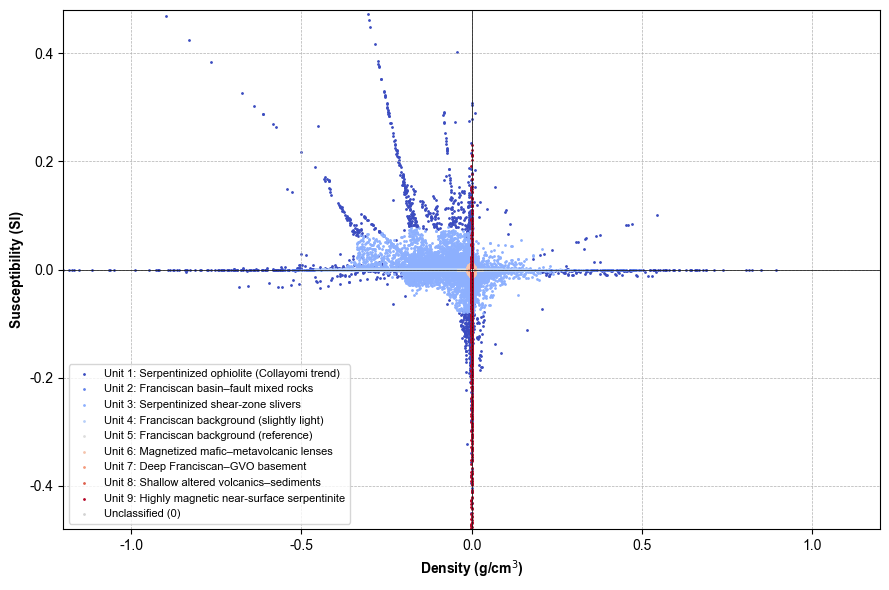

Saved: Figure\FigureS4_Hannah_GPT_auto_group_crossplot.png


In [13]:
# -------------------------
# Block 3: Property-Space Crossplot (Hannah_Inversion_GPT_auto_group)
# -------------------------
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["axes.unicode_minus"] = False

ROOT = globals().get("ROOT", Path.cwd())
proj_dir = ROOT / "Hannah_Inversion_GPT_auto_group"
res_dir = proj_dir / "inversion_result"
geo_dir = proj_dir / "geology_models"

# Core inversion properties
dens = np.load(res_dir / "joint_density_core.npy")
susc = np.load(res_dir / "joint_susceptibility_core.npy")

unit_path = geo_dir / "unit_id_3d.npy"
if not unit_path.exists():
    unit_path = geo_dir / "geo_id_3d.npy"
if not unit_path.exists():
    raise FileNotFoundError(f"Missing labels: {unit_path}")
unit_id = np.load(unit_path).astype(int)

if dens.shape != susc.shape or dens.shape != unit_id.shape:
    raise ValueError(f"Shape mismatch: dens={dens.shape}, susc={susc.shape}, unit={unit_id.shape}")

# Optional readable names for legend
unit_defs = {}
unit_defs_csv = proj_dir / "Hannah_unit_defs.csv"
if unit_defs_csv.exists():
    df_unit = pd.read_csv(unit_defs_csv)
    if {"unit_id", "name"}.issubset(df_unit.columns):
        for r in df_unit.itertuples(index=False):
            unit_defs[int(r.unit_id)] = str(r.name)

print(f"Using labels: {unit_path.relative_to(ROOT)}")
if unit_defs:
    print(f"Using unit defs: {unit_defs_csv.relative_to(ROOT)}")

x = dens.ravel()
y = susc.ravel()
u = unit_id.astype(int).ravel()

unique_ids = np.unique(u)
has_zero = 0 in unique_ids
unique_ids = np.sort(unique_ids[unique_ids != 0])

n_ids = len(unique_ids)
cmap = mpl.colormaps.get_cmap("coolwarm").resampled(max(n_ids, 1))

plt.figure(figsize=(9, 6))
for i, uid in enumerate(unique_ids):
    mask = u == uid
    if not np.any(mask):
        continue
    uname = unit_defs.get(int(uid), "")
    label = f"Unit {uid}: {uname}" if uname else f"Unit {uid}"
    plt.scatter(
        x[mask],
        y[mask],
        s=1,
        alpha=1,
        color=cmap(i),
        label=label,
    )

if has_zero:
    mask0 = u == 0
    if np.any(mask0):
        plt.scatter(
            x[mask0],
            y[mask0],
            s=1,
            alpha=1,
            color="lightgray",
            label="Unclassified (0)",
        )

plt.axhline(0.0, color="k", linewidth=0.5)
plt.axvline(0.0, color="k", linewidth=0.5)

# Fixed display range for consistent visual comparison
dens_min, dens_max = -1, 1
susc_min, susc_max = -0.4, 0.4

dens_pad = (dens_max - dens_min) * 0.1 if dens_max != dens_min else 0.1
susc_pad = (susc_max - susc_min) * 0.1 if susc_max != susc_min else 0.01

plt.xlim(dens_min - dens_pad, dens_max + dens_pad)
plt.ylim(susc_min - susc_pad, susc_max + susc_pad)

plt.xlabel(r"Density (g/cm$^3$)", fontweight="bold")
plt.ylabel("Susceptibility (SI)", fontweight="bold")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend(loc="lower left", fontsize=8, frameon=True)
plt.tight_layout()

out_dir = ROOT / "Figure"
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "FigureS4_Hannah_GPT_auto_group_crossplot.png"
plt.savefig(out_png, dpi=600)
plt.show()
print(f"Saved: {out_png.relative_to(ROOT)}")



## Block 4: Slice Comparison Between Predefined and Autonomous Grouping

Plot a 4x3 matrix comparing GPT predefined grouping and auto-grouping in XY and XZ sections.


GPT uses geo labels: Hannah_Inversion_GPT\geology_models\geo_id_3d.npy
GPT_auto_group uses geo labels: Hannah_Inversion_GPT_auto_group\geology_models\geo_id_3d_reordered.npy


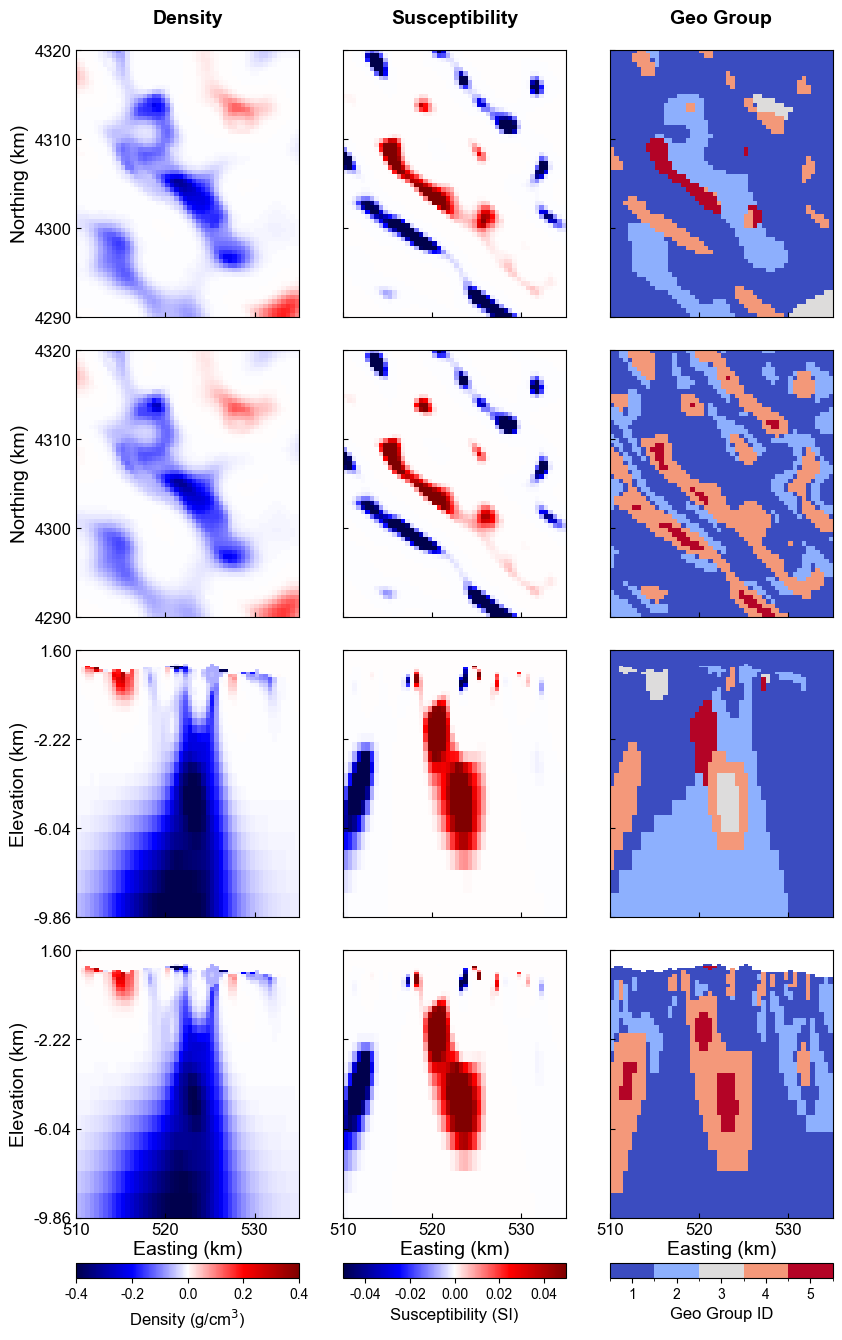

Saved: Figure\Figure9_Hannah_slices_comparison_auto_group.png


In [14]:
# -------------------------
# Block 4: GPT vs GPT_auto_group Slice Comparison (4x3)
# Rows 1-2: XY depth slices (z = -2524 m)
# Rows 3-4: XZ sections (y = 4303250 m)
# -------------------------
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from pathlib import Path

# Global font settings
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()

z_target_m = -2524.0
y_target_m = 4303250.0

model_specs = [
    ("GPT", ROOT / "Hannah_Inversion_GPT"),
    ("GPT_auto_group", ROOT / "Hannah_Inversion_GPT_auto_group"),
]


from notebook_geo_helpers import read_ubc_tensor_mesh

def load_model_pack(model_name: str, proj_dir: Path):
    dens = np.load(proj_dir / "inversion_result" / "joint_density_core.npy")
    susc = np.load(proj_dir / "inversion_result" / "joint_susceptibility_core.npy")

    if model_name == "GPT_auto_group":
        geo_path = proj_dir / "geology_models" / "geo_id_3d_reordered.npy"
    else:
        geo_path = proj_dir / "geology_models" / "geo_id_3d.npy"

    if not geo_path.exists():
        raise FileNotFoundError(f"No geo labels found: {geo_path}")

    geo = np.load(geo_path).astype(int)

    mesh_path = proj_dir / "mesh" / "mesh_core.msh"
    (nx, ny, nz), x_edges, y_edges, z_edges, x_centers, y_centers, z_centers = read_ubc_tensor_mesh(mesh_path)

    if dens.shape != susc.shape or dens.shape != geo.shape:
        raise ValueError(f"Shape mismatch in {model_name}: dens={dens.shape}, susc={susc.shape}, geo={geo.shape}")
    if dens.shape != (nx, ny, nz):
        raise ValueError(f"Mesh mismatch in {model_name}: mesh={(nx, ny, nz)} vs data={dens.shape}")

    print(f"{model_name} uses geo labels: {geo_path.relative_to(ROOT)}")

    return {
        "model": model_name,
        "dens": dens,
        "susc": susc,
        "geo": geo,
        "x_edges": x_edges,
        "y_edges": y_edges,
        "z_edges": z_edges,
        "x_centers": x_centers,
        "y_centers": y_centers,
        "z_centers": z_centers,
    }


# -------------------------
# Read all model packs
# -------------------------
packs = {name: load_model_pack(name, pdir) for name, pdir in model_specs}

all_geo_vals = []
for d in packs.values():
    all_geo_vals.extend(np.unique(d["geo"]).tolist())
geo_values = np.array(sorted(set(int(v) for v in all_geo_vals if int(v) != 0)), dtype=int)
if geo_values.size == 0:
    geo_values = np.array([1], dtype=int)

if geo_values.size == 1:
    geo_bounds = np.array([geo_values[0] - 0.5, geo_values[0] + 0.5], dtype=float)
else:
    geo_bounds = np.empty(geo_values.size + 1, dtype=float)
    geo_bounds[1:-1] = 0.5 * (geo_values[:-1] + geo_values[1:])
    geo_bounds[0] = geo_values[0] - 0.5
    geo_bounds[-1] = geo_values[-1] + 0.5

cmap_cont = plt.get_cmap("seismic")
geo_base = plt.get_cmap("coolwarm")
geo_colors = geo_base(np.linspace(0.0, 1.0, geo_values.size))
cmap_geo = ListedColormap(geo_colors, name="coolwarm_discussion_geo")
norm_geo = BoundaryNorm(geo_bounds, cmap_geo.N, clip=True)

# fixed color scales consistent with previous slice plotting
dens_vmin, dens_vmax = -0.4, 0.4
susc_vmin, susc_vmax = -0.05, 0.05

rows = [
    ("xy", "GPT", "GPT"),
    ("xy", "GPT_auto_group", "GPT_auto_group"),
    ("xz", "GPT", "GPT"),
    ("xz", "GPT_auto_group", "GPT_auto_group"),
]

n_rows = len(rows)
fig = plt.figure(figsize=(10, 15), constrained_layout=False)
gs = fig.add_gridspec(
    nrows=n_rows + 1,
    ncols=3,
    height_ratios=[1.0] * n_rows + [0.11],
    left=0.16,
    right=0.95,
    top=0.94,
    bottom=0.12,
    wspace=0.04,
    hspace=0.15,
)

axes = np.empty((n_rows, 3), dtype=object)
for r in range(n_rows):
    for c in range(3):
        axes[r, c] = fig.add_subplot(gs[r, c])

# Keep XZ rows close to XY panel width
first_pack = packs[rows[0][1]]
xy_box_aspect = (first_pack["y_edges"][-1] - first_pack["y_edges"][0]) / (first_pack["x_edges"][-1] - first_pack["x_edges"][0])

m_d_ref = None
m_s_ref = None
m_g_ref = None

for r, (mode, model_key, _) in enumerate(rows):
    d = packs[model_key]

    dens = d["dens"]
    susc = d["susc"]
    geo = d["geo"]

    x_edges_km = d["x_edges"] / 1000.0
    y_edges_km = d["y_edges"] / 1000.0
    z_edges_km = d["z_edges"] / 1000.0

    x_centers = d["x_centers"]
    y_centers = d["y_centers"]
    z_centers = d["z_centers"]

    ax_d, ax_s, ax_g = axes[r, 0], axes[r, 1], axes[r, 2]

    if mode == "xy":
        k = int(np.argmin(np.abs(z_centers - z_target_m)))

        dens_slice = dens[:, :, k].T
        susc_slice = susc[:, :, k].T
        geo_slice = np.ma.masked_where(geo[:, :, k].T == 0, geo[:, :, k].T)

        m_d = ax_d.imshow(
            dens_slice,
            origin="lower",
            extent=[x_edges_km[0], x_edges_km[-1], y_edges_km[0], y_edges_km[-1]],
            cmap=cmap_cont,
            vmin=dens_vmin,
            vmax=dens_vmax,
            interpolation="nearest",
        )
        m_s = ax_s.imshow(
            susc_slice,
            origin="lower",
            extent=[x_edges_km[0], x_edges_km[-1], y_edges_km[0], y_edges_km[-1]],
            cmap=cmap_cont,
            vmin=susc_vmin,
            vmax=susc_vmax,
            interpolation="nearest",
        )
        m_g = ax_g.imshow(
            geo_slice,
            origin="lower",
            extent=[x_edges_km[0], x_edges_km[-1], y_edges_km[0], y_edges_km[-1]],
            cmap=cmap_geo,
            norm=norm_geo,
            interpolation="nearest",
        )

        for ax in (ax_d, ax_s, ax_g):
            ax.set_ylim(y_edges_km[0], y_edges_km[-1])

        ylab = "Northing (km)"

    else:
        j = int(np.argmin(np.abs(y_centers - y_target_m)))

        dens_sec = dens[:, j, :].T
        susc_sec = susc[:, j, :].T
        geo_sec = np.ma.masked_where(geo[:, j, :].T == 0, geo[:, j, :].T)

        m_d = ax_d.pcolormesh(
            x_edges_km,
            z_edges_km,
            dens_sec,
            shading="auto",
            cmap=cmap_cont,
            vmin=dens_vmin,
            vmax=dens_vmax,
        )
        m_s = ax_s.pcolormesh(
            x_edges_km,
            z_edges_km,
            susc_sec,
            shading="auto",
            cmap=cmap_cont,
            vmin=susc_vmin,
            vmax=susc_vmax,
        )
        m_g = ax_g.pcolormesh(
            x_edges_km,
            z_edges_km,
            geo_sec,
            shading="auto",
            cmap=cmap_geo,
            norm=norm_geo,
        )

        for ax in (ax_d, ax_s, ax_g):
            ax.set_ylim(z_edges_km[0], z_edges_km[-1])

        ylab = "Elevation (km)"

    for c, ax in enumerate((ax_d, ax_s, ax_g)):
        ax.set_xlim(x_edges_km[0], x_edges_km[-1])
        ax.set_xticks([510, 520, 530])

        y0, y1 = ax.get_ylim()
        ax.set_yticks(np.linspace(y0, y1, 4))
        ax.tick_params(direction="in", labelsize=12)

        if mode == "xz":
            ax.set_aspect("auto")
            ax.set_box_aspect(xy_box_aspect)

        if r == n_rows - 1:
            ax.set_xlabel("Easting (km)", labelpad=2, fontsize=14)
        else:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)

        if c == 0:
            ax.set_ylabel(ylab, fontsize=14)
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

    if m_d_ref is None:
        m_d_ref = m_d
    if m_s_ref is None:
        m_s_ref = m_s
    if m_g_ref is None:
        m_g_ref = m_g

# Column headers at top
col_titles = ["Density", "Susceptibility", "Geo Group"]
for c, title in enumerate(col_titles):
    pos = axes[0, c].get_position()
    xc = 0.5 * (pos.x0 + pos.x1)
    fig.text(xc, 0.955, title, ha="center", va="bottom", fontsize=14, fontweight="bold")

# Bottom colorbars (3 shared bars)
fig.canvas.draw()
cb_h = 0.01
cb_gap = 0.03

pos_d = axes[n_rows - 1, 0].get_position()
pos_s = axes[n_rows - 1, 1].get_position()
pos_g = axes[n_rows - 1, 2].get_position()

cax_d = fig.add_axes([pos_d.x0, pos_d.y0 - cb_gap - cb_h, pos_d.width, cb_h])
cax_s = fig.add_axes([pos_s.x0, pos_s.y0 - cb_gap - cb_h, pos_s.width, cb_h])
cax_g = fig.add_axes([pos_g.x0, pos_g.y0 - cb_gap - cb_h, pos_g.width, cb_h])

cbar_d = fig.colorbar(m_d_ref, cax=cax_d, orientation="horizontal")
cbar_d.set_label(r"Density (g/cm$^3$)", fontsize=12)

cbar_s = fig.colorbar(m_s_ref, cax=cax_s, orientation="horizontal")
cbar_s.set_label("Susceptibility (SI)", fontsize=12)

cbar_g = fig.colorbar(m_g_ref, cax=cax_g, orientation="horizontal")
cbar_g.set_label("Geo Group ID", fontsize=12)
if geo_values.size <= 12:
    cbar_g.set_ticks(geo_values)
else:
    step = int(np.ceil(geo_values.size / 12))
    cbar_g.set_ticks(geo_values[::step])

out_dir = ROOT / "Figure"
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "Figure9_Hannah_slices_comparison_auto_group.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.relative_to(ROOT)}")



## Block 5: 2x3 Pseudo-Geology 3D Summary

Build one no-background 3D view plus five single-Geo-ID panels with a shared layout and global colorbar.


Using geo labels: Hannah_Inversion_GPT_auto_group\geology_models\geo_id_3d_reordered.npy


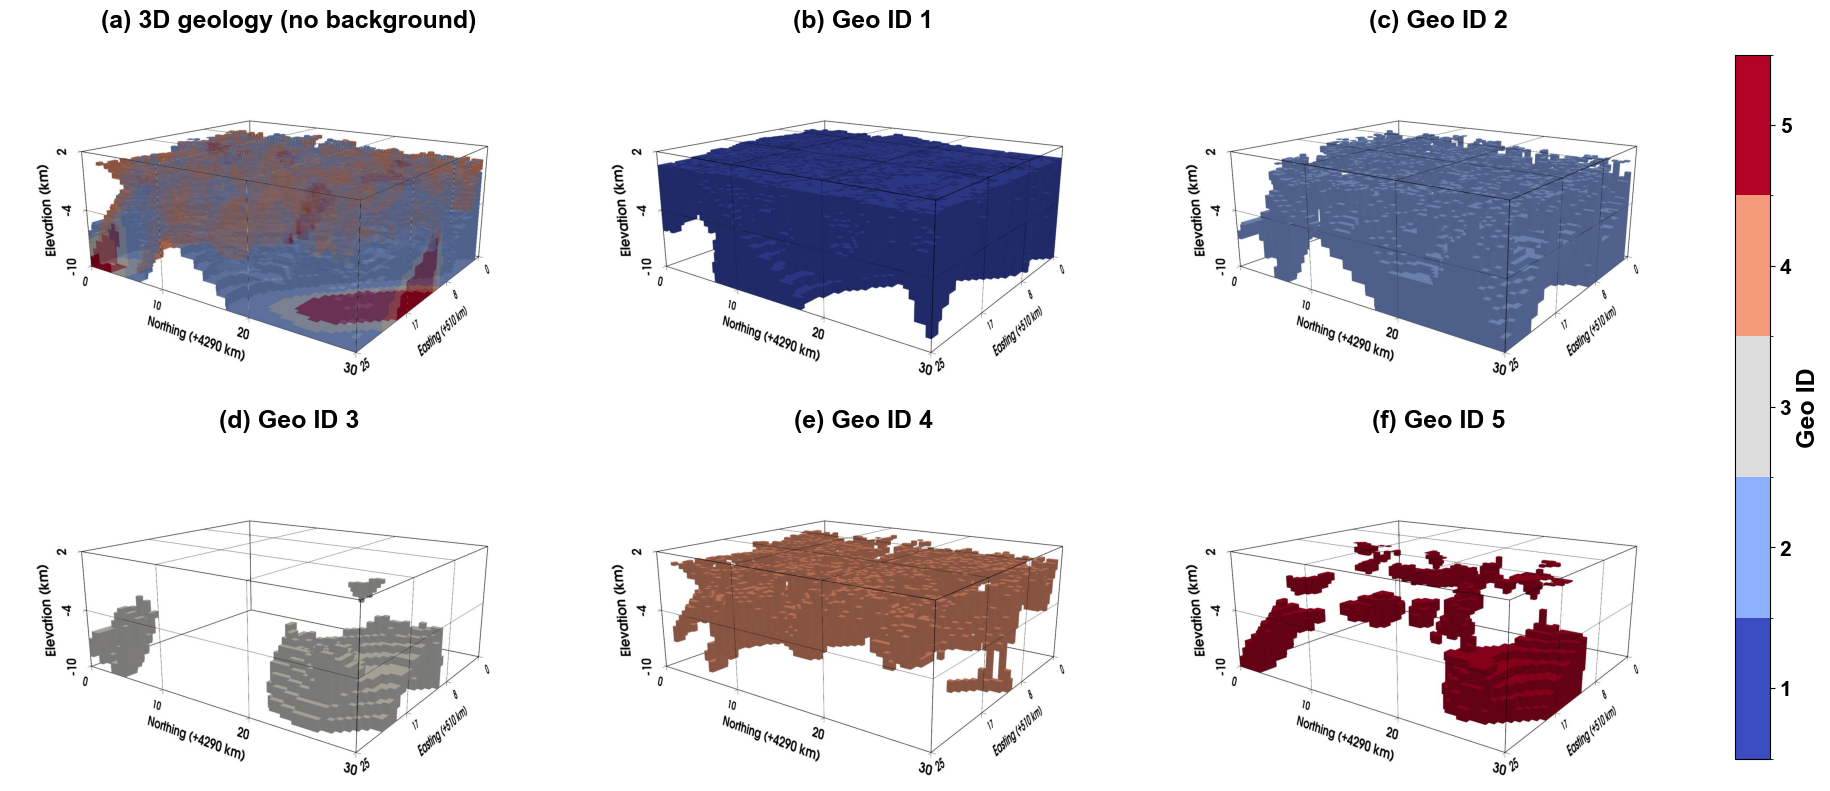

Saved 2x3 summary: Figure\Figure10_Hannah_geo_3d_auto_group.png


In [15]:
# -------------------------
# Block 5: 2x3 Pseudo-Geology 3D Summary
# -------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path
import pyvista as pv

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]

ROOT = Path.cwd()
proj_dir = ROOT / "Hannah_Inversion_GPT_auto_group"
mesh_path = proj_dir / "mesh" / "mesh_core.msh"
geo_id_path = proj_dir / "geology_models" / "geo_id_3d_reordered.npy"
if not geo_id_path.exists():
    raise FileNotFoundError(f"Cannot find geo labels: {geo_id_path}")
print(f"Using geo labels: {geo_id_path.relative_to(ROOT)}")


from notebook_geo_helpers import read_ubc_tensor_mesh


def setup_bounds(plotter, grid_obj, font_size=30):
    xmin, xmax, ymin, ymax, zmin, zmax = grid_obj.bounds

    # Match 3_1 style: relative km axes from local origin.
    xmin_km, xmax_km = xmin / 1000.0, xmax / 1000.0
    ymin_km, ymax_km = ymin / 1000.0, ymax / 1000.0
    zmin_km, zmax_km = zmin / 1000.0, zmax / 1000.0
    dx_km = xmax_km - xmin_km
    dy_km = ymax_km - ymin_km

    actor = plotter.show_bounds(
        grid="front",
        location="outer",
        all_edges=False,
        xtitle=f"Easting (+{xmin_km:.0f} km)",
        ytitle=f"Northing (+{ymin_km:.0f} km)",
        ztitle="Elevation (km)",
        axes_ranges=[0.0, dx_km, 0.0, dy_km, zmin_km, zmax_km],
        fmt="%.0f",
        font_size=font_size,
        n_xlabels=4,
        n_ylabels=4,
        n_zlabels=3,
    )

    actor.SetTickLocationToOutside()
    # Match 3_1 style: X/Y integer labels, Z one decimal.
    if hasattr(actor, "SetLabelFormat"):
        actor.SetLabelFormat("%.1f")
    if hasattr(actor, "SetXLabelFormat"):
        actor.SetXLabelFormat("%.0f")
    if hasattr(actor, "SetYLabelFormat"):
        actor.SetYLabelFormat("%.0f")
    if hasattr(actor, "SetZLabelFormat"):
        actor.SetZLabelFormat("%.1f")
    actor.label_offset = 30


def setup_camera(plotter, grid_obj, zoom=1.0):
    xmin, xmax, ymin, ymax, zmin, zmax = grid_obj.bounds
    center = ((xmin + xmax) / 2, (ymin + ymax) / 2, (zmin + zmax) / 2)
    dx, dy, dz = xmax - xmin, ymax - ymin, zmax - zmin
    plotter.camera_position = [
        (center[0] + 2 * dx, center[1] + 1.2*dy, center[2] + 1.5 * dz),
        center,
        (0, 0, 1),
    ]
    plotter.camera.zoom(zoom)


(nx, ny, nz), x_edges, y_edges, z_edges, _, _, _ = read_ubc_tensor_mesh(mesh_path)
geo_id_3d = np.load(geo_id_path).astype(np.int16)
if geo_id_3d.shape != (nx, ny, nz):
    raise ValueError(f"geo_id shape {geo_id_3d.shape} != mesh shape {(nx, ny, nz)}")

# Build rectilinear grid
grid = pv.RectilinearGrid(
    np.asarray(x_edges, dtype=float),
    np.asarray(y_edges, dtype=float),
    np.asarray(z_edges, dtype=float),
)
geo_flat_plot = geo_id_3d.ravel(order="F").astype(np.int16)
grid.cell_data["geo_id"] = geo_flat_plot

all_geo_ids = np.unique(geo_flat_plot)
all_geo_ids = all_geo_ids[all_geo_ids > 0]
if all_geo_ids.size == 0:
    raise ValueError("No positive geo IDs found for 3D plotting.")

min_id = int(np.min(all_geo_ids))
max_id = int(np.max(all_geo_ids))
n_colors = max_id - min_id + 1
base = mpl.colormaps.get_cmap("coolwarm").resampled(max(n_colors, 1))
colors = [base(i) for i in range(n_colors)]
cmap_geo = ListedColormap(colors)
clim = (min_id, max_id)

panel_dir = ROOT / "Figure" / "Hannah_discussion_geo3d_panels"
panel_dir.mkdir(parents=True, exist_ok=True)

# Panel 1: overall without background (remove geo_id 0 and 1)
mask_nobg = (geo_flat_plot != 0) & (geo_flat_plot != 1)
if not np.any(mask_nobg):
    mask_nobg = geo_flat_plot != 0

overall_path = panel_dir / "geo_model_without_background.jpg"
if np.any(mask_nobg):
    grid_nobg = grid.extract_cells(mask_nobg)
    p = pv.Plotter(off_screen=True, window_size=(1600, 1000))
    p.set_background("white")
    p.add_mesh(
        grid_nobg,
        scalars="geo_id",
        cmap=cmap_geo,
        show_edges=False,
        show_scalar_bar=False,
        opacity=0.95,
        clim=clim,
    )
    p.add_mesh(grid.outline(), color="black", line_width=2)
    setup_bounds(p, grid)
    setup_camera(p, grid, zoom=1.0)
    p.screenshot(str(overall_path))
    p.close()

single_paths = []
for gid in [1, 2, 3, 4, 5]:
    out_single = panel_dir / f"geo_id_{gid}.jpg"
    mask_show = geo_flat_plot == gid
    if np.any(mask_show):
        grid_show = grid.extract_cells(mask_show)
        p = pv.Plotter(off_screen=True, window_size=(1600, 1000))
        p.set_background("white")
        p.add_mesh(
            grid_show,
            scalars="geo_id",
            cmap=cmap_geo,
            show_edges=False,
            show_scalar_bar=False,
            opacity=1.0,
            clim=clim,
        )
        p.add_mesh(grid.outline(), color="black", line_width=2)
        setup_bounds(p, grid)
        setup_camera(p, grid, zoom=1.0)
        p.screenshot(str(out_single))
        p.close()
    single_paths.append((gid, out_single if out_single.exists() else None))

# Compose to 2x3
fig, axes = plt.subplots(2, 3, figsize=(20, 8), constrained_layout=False)
axes = axes.ravel()
fig.subplots_adjust(left=0.02, right=0.90, top=1.0, bottom=0.0, wspace=0.03, hspace=0.00)

panel_items = [overall_path if overall_path.exists() else None]
panel_items += [pth for _, pth in single_paths]


panel_titles = [
    "(a) 3D geology (no background)",
    "(b) Geo ID 1",
    "(c) Geo ID 2",
    "(d) Geo ID 3",
    "(e) Geo ID 4",
    "(f) Geo ID 5",
]

for i, (ax, img_path) in enumerate(zip(axes, panel_items)):
    if img_path is not None and Path(img_path).exists():
        img = plt.imread(img_path)
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "Not found", ha="center", va="center", fontsize=12)
    ax.set_title(panel_titles[i], fontsize=18, pad=2, fontweight="bold")
    ax.axis("off")

# One global colorbar
bounds = np.arange(min_id - 0.5, max_id + 1.5, 1.0)
norm = BoundaryNorm(bounds, ncolors=cmap_geo.N, clip=True)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_geo)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.020, pad=0.01)
cbar.set_label("Geo ID", fontsize=18, fontweight="bold")
cbar.ax.tick_params(labelsize=15)
for t in cbar.ax.get_yticklabels():
    t.set_fontweight("bold")
    t.set_fontname("Arial")
cbar.set_ticks(np.arange(min_id, max_id + 1, 1))

out_dir = ROOT / "Figure"
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / "Figure10_Hannah_geo_3d_auto_group.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved 2x3 summary: {out_png.relative_to(ROOT)}")
